Saving sales_dataset_task2.csv to sales_dataset_task2.csv
   Row ID        Order ID  Order Date   Ship Date       Ship Mode  \
0       1  CA-2019-100001  19-12-2019  21-12-2019  Standard Class   
1       2  CA-2019-100002  21-04-2019  25-04-2019    Second Class   
2       3  CA-2019-100003  24-10-2019  27-10-2019     First Class   
3       4  CA-2019-100004  02-10-2019  07-10-2019     First Class   
4       5  CA-2019-100005  11-03-2019  15-03-2019  Standard Class   

    Customer Name      Segment Country         City       State   Region  \
0  James Anderson     Consumer     USA  San Antonio       Texas  Central   
1     Liam Walker     Consumer     USA      Phoenix     Arizona     West   
2      John Smith  Home Office     USA    San Diego  California     West   
3      John Smith  Home Office     USA      Houston       Texas  Central   
4    David Wilson     Consumer     USA  Los Angeles  California     West   

          Category Sub-Category   Sales  Quantity  Discount  
0       

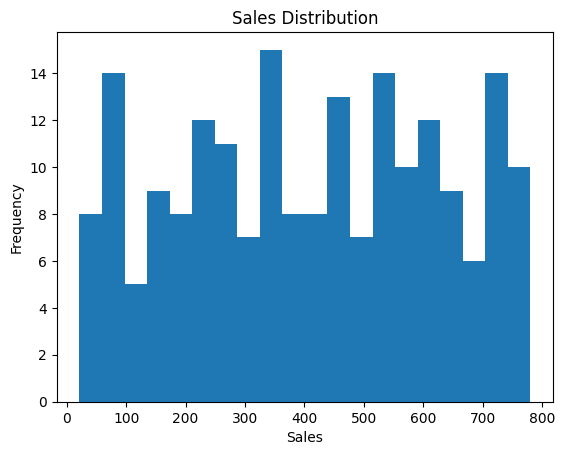

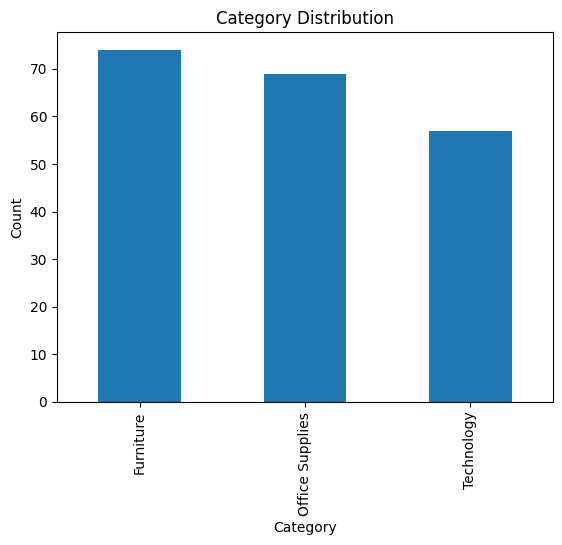

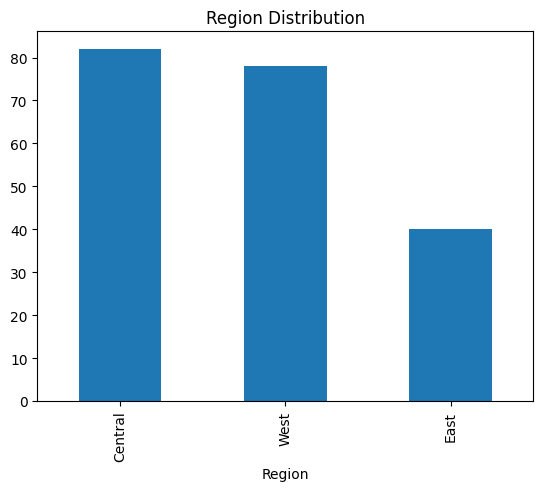

          Category  Total_Sales
0        Furniture     30315.85
1  Office Supplies     29541.52
2       Technology     22051.60
    Region  Total_Sales
0  Central     33244.31
1     East     17818.17
2     West     30846.49
       Segment   Avg_Sales
0     Consumer  429.802000
1    Corporate  401.244375
2  Home Office  393.347213


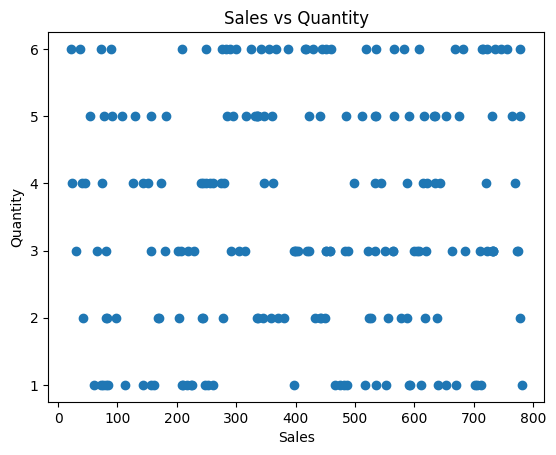

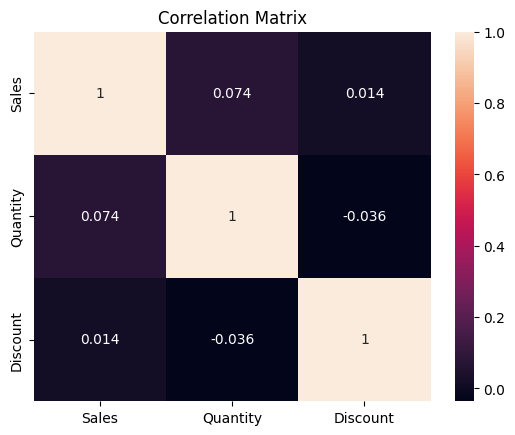

Total Sales: 81908.97
Total Orders: 200
Average Sales: 409.54485


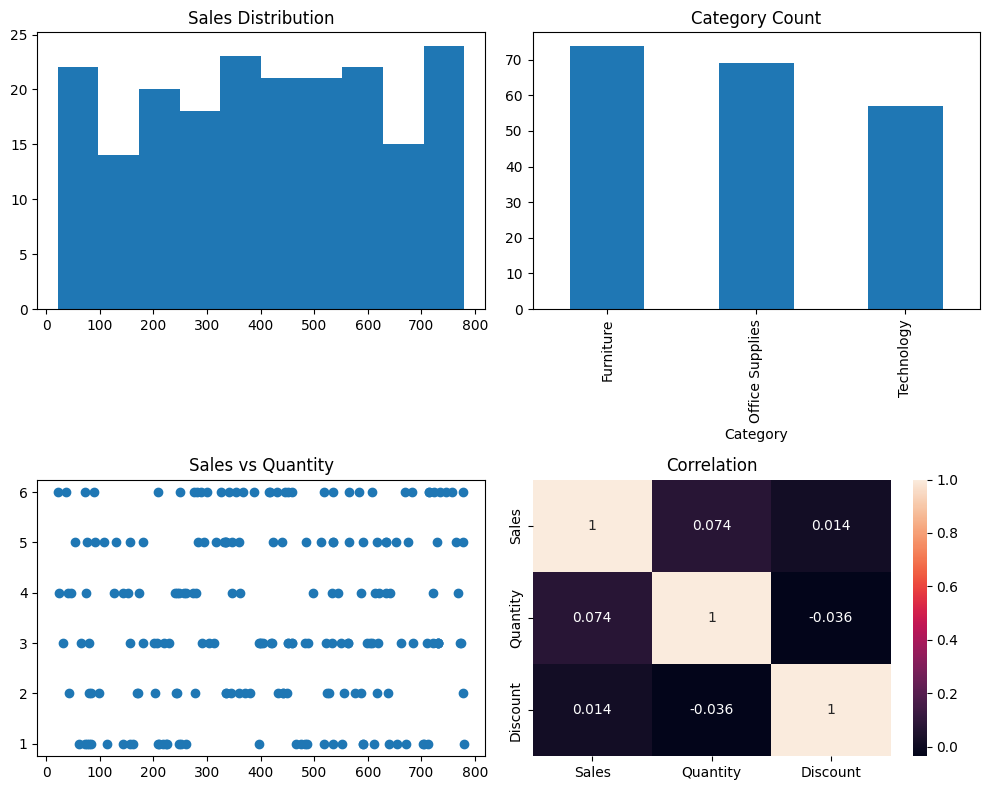

In [3]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

df = pd.read_csv("sales_dataset_task2.csv")

print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())

print("Total Sales:", df["Sales"].sum())
print("Average Sales:", df["Sales"].mean())
print("Maximum Sales:", df["Sales"].max())
print("Minimum Sales:", df["Sales"].min())

plt.hist(df["Sales"], bins=20)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

df["Category"].value_counts().plot(kind="bar")
plt.title("Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

df["Region"].value_counts().plot(kind="bar")
plt.title("Region Distribution")
plt.show()

conn = sqlite3.connect("sales.db")
df.to_sql("sales", conn, if_exists="replace", index=False)

query1 = """
SELECT Category, SUM(Sales) as Total_Sales
FROM sales
GROUP BY Category
"""
print(pd.read_sql(query1, conn))

query2 = """
SELECT Region, SUM(Sales) as Total_Sales
FROM sales
GROUP BY Region
"""
print(pd.read_sql(query2, conn))

query3 = """
SELECT Segment, AVG(Sales) as Avg_Sales
FROM sales
GROUP BY Segment
"""
print(pd.read_sql(query3, conn))

plt.scatter(df["Sales"], df["Quantity"])
plt.xlabel("Sales")
plt.ylabel("Quantity")
plt.title("Sales vs Quantity")
plt.show()

corr = df[["Sales","Quantity","Discount"]].corr()

sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()

total_sales = df["Sales"].sum()
total_orders = df["Order ID"].count()
avg_sales = df["Sales"].mean()

print("Total Sales:", total_sales)
print("Total Orders:", total_orders)
print("Average Sales:", avg_sales)

fig, ax = plt.subplots(2,2, figsize=(10,8))

ax[0,0].hist(df["Sales"])
ax[0,0].set_title("Sales Distribution")

df["Category"].value_counts().plot(kind="bar", ax=ax[0,1])
ax[0,1].set_title("Category Count")

ax[1,0].scatter(df["Sales"], df["Quantity"])
ax[1,0].set_title("Sales vs Quantity")

sns.heatmap(corr, annot=True, ax=ax[1,1])
ax[1,1].set_title("Correlation")

plt.tight_layout()
plt.show()